In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

base_path = '/kaggle/input/affectnet/archive (3)'
train_path = os.path.join(base_path, 'Train')
test_path = os.path.join(base_path, 'Test')

print("Checking dataset structure...")
print(f"\nTrain path exists: {os.path.exists(train_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

print("\nEmotion folders in Train:")
train_emotions = sorted(os.listdir(train_path))
for emotion in train_emotions:
    emotion_path = os.path.join(train_path, emotion)
    if os.path.isdir(emotion_path):
        count = len(os.listdir(emotion_path))
        print(f"{emotion}: {count} images")

print("\nEmotion folders in Test:")
test_emotions = sorted(os.listdir(test_path))
for emotion in test_emotions:
    emotion_path = os.path.join(test_path, emotion)
    if os.path.isdir(emotion_path):
        count = len(os.listdir(emotion_path))
        print(f"{emotion}: {count} images")

print(f"\nTotal train emotions: {len(train_emotions)}")
print(f"Total test emotions: {len(test_emotions)}")

Checking dataset structure...

Train path exists: True
Test path exists: True

Emotion folders in Train:
anger: 1500 images
contempt: 1559 images
disgust: 1229 images
fear: 1512 images
happy: 2340 images
neutral: 2758 images
sad: 3091 images
surprise: 2119 images

Emotion folders in Test:
Anger: 1718 images
Contempt: 1312 images
disgust: 1248 images
fear: 1664 images
happy: 2704 images
neutral: 2368 images
sad: 1584 images
surprise: 1920 images

Total train emotions: 8
Total test emotions: 8


In [3]:
import matplotlib.pyplot as plt
import cv2
from collections import Counter

emotion_map = {
    'anger': 'Angry',
    'Anger': 'Angry',
    'contempt': 'Contempt',
    'Contempt': 'Contempt',
    'disgust': 'Disgust',
    'fear': 'Fear',
    'happy': 'Happy',
    'neutral': 'Neutral',
    'sad': 'Sad',
    'surprise': 'Surprise'
}

train_data = []
for emotion_folder in train_emotions:
    emotion_path = os.path.join(train_path, emotion_folder)
    emotion_label = emotion_map[emotion_folder]
    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)
        train_data.append({'path': img_path, 'emotion': emotion_label})

test_data = []
for emotion_folder in test_emotions:
    emotion_path = os.path.join(test_path, emotion_folder)
    emotion_label = emotion_map[emotion_folder]
    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)
        test_data.append({'path': img_path, 'emotion': emotion_label})

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print(f"Total training samples: {len(train_df)}")
print(f"Total testing samples: {len(test_df)}")
print(f"\nTraining distribution:")
print(train_df['emotion'].value_counts().sort_index())
print(f"\nTesting distribution:")
print(test_df['emotion'].value_counts().sort_index())

Total training samples: 16108
Total testing samples: 14518

Training distribution:
emotion
Angry       1500
Contempt    1559
Disgust     1229
Fear        1512
Happy       2340
Neutral     2758
Sad         3091
Surprise    2119
Name: count, dtype: int64

Testing distribution:
emotion
Angry       1718
Contempt    1312
Disgust     1248
Fear        1664
Happy       2704
Neutral     2368
Sad         1584
Surprise    1920
Name: count, dtype: int64


In [4]:
merge_contempt_with_disgust = True

if merge_contempt_with_disgust:
    train_df['emotion'] = train_df['emotion'].replace('Contempt', 'Disgust')
    test_df['emotion'] = test_df['emotion'].replace('Contempt', 'Disgust')
    print("Merged Contempt into Disgust")
else:
    print("Keeping Contempt as separate emotion")

print(f"\nFinal training distribution:")
print(train_df['emotion'].value_counts().sort_index())
print(f"\nFinal testing distribution:")
print(test_df['emotion'].value_counts().sort_index())

emotion_classes = sorted(train_df['emotion'].unique())
num_classes = len(emotion_classes)
print(f"\nTotal emotion classes: {num_classes}")
print(f"Classes: {emotion_classes}")

Merged Contempt into Disgust

Final training distribution:
emotion
Angry       1500
Disgust     2788
Fear        1512
Happy       2340
Neutral     2758
Sad         3091
Surprise    2119
Name: count, dtype: int64

Final testing distribution:
emotion
Angry       1718
Disgust     2560
Fear        1664
Happy       2704
Neutral     2368
Sad         1584
Surprise    1920
Name: count, dtype: int64

Total emotion classes: 7
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


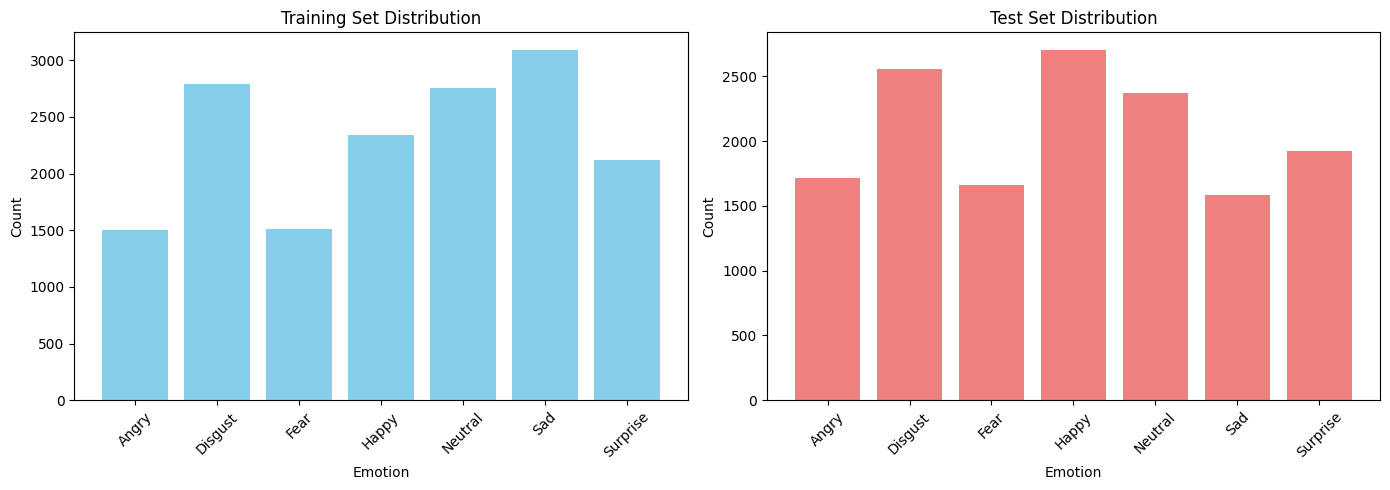


Class imbalance ratio: 2.06x
Most samples: 3091 (Sad)
Least samples: 1500 (Angry)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = train_df['emotion'].value_counts().sort_index()
test_counts = test_df['emotion'].value_counts().sort_index()

axes[0].bar(train_counts.index, train_counts.values, color='skyblue')
axes[0].set_title('Training Set Distribution')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(test_counts.index, test_counts.values, color='lightcoral')
axes[1].set_title('Test Set Distribution')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

max_count = train_counts.max()
min_count = train_counts.min()
imbalance_ratio = max_count / min_count
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}x")
print(f"Most samples: {max_count} ({train_counts.idxmax()})")
print(f"Least samples: {min_count} ({train_counts.idxmin()})")

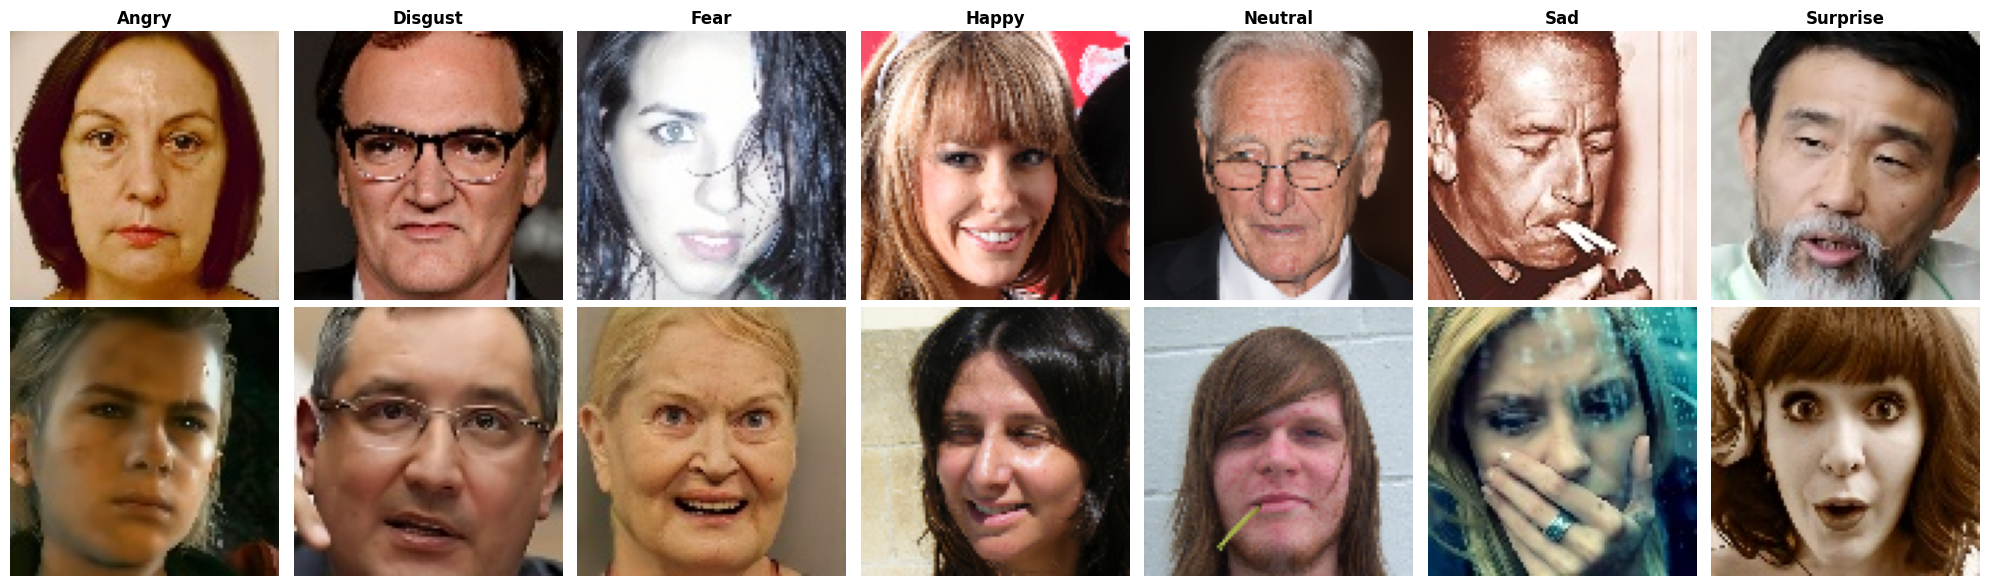


Sample image shape: (96, 96, 3)
Image type: RGB
Channels: 3


In [6]:
fig, axes = plt.subplots(2, 7, figsize=(20, 6))

for idx, emotion in enumerate(emotion_classes):
    emotion_samples = train_df[train_df['emotion'] == emotion].sample(2)
    
    for i, (_, row) in enumerate(emotion_samples.iterrows()):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i, idx].imshow(img)
        axes[i, idx].axis('off')
        if i == 0:
            axes[i, idx].set_title(emotion, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

sample_img = cv2.imread(train_df.iloc[0]['path'])
print(f"\nSample image shape: {sample_img.shape}")
print(f"Image type: {'RGB' if len(sample_img.shape) == 3 else 'Grayscale'}")
print(f"Channels: {sample_img.shape[2] if len(sample_img.shape) == 3 else 1}")

In [7]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array(emotion_classes),
    y=train_df['emotion']
)

class_weights = dict(zip(range(num_classes), class_weights_array))

print("Class weights for balanced training:")
for idx, emotion in enumerate(emotion_classes):
    print(f"{emotion}: {class_weights[idx]:.3f}")

target_samples = int(train_counts.max() * 0.8)
print(f"\nTarget samples per class after oversampling: {target_samples}")

balanced_train_data = []
for emotion in emotion_classes:
    emotion_data = train_df[train_df['emotion'] == emotion]
    current_count = len(emotion_data)
    
    if current_count < target_samples:
        oversample_count = target_samples - current_count
        oversampled = emotion_data.sample(n=oversample_count, replace=True, random_state=42)
        balanced_train_data.append(emotion_data)
        balanced_train_data.append(oversampled)
    else:
        balanced_train_data.append(emotion_data)

train_df_balanced = pd.concat(balanced_train_data, ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced training distribution:")
print(train_df_balanced['emotion'].value_counts().sort_index())
print(f"\nTotal training samples after balancing: {len(train_df_balanced)}")

Class weights for balanced training:
Angry: 1.534
Disgust: 0.825
Fear: 1.522
Happy: 0.983
Neutral: 0.834
Sad: 0.744
Surprise: 1.086

Target samples per class after oversampling: 2472

Balanced training distribution:
emotion
Angry       2472
Disgust     2788
Fear        2472
Happy       2472
Neutral     2758
Sad         3091
Surprise    2472
Name: count, dtype: int64

Total training samples after balancing: 18525


In [8]:
from sklearn.model_selection import train_test_split

train_final, val_df = train_test_split(
    train_df_balanced, 
    test_size=0.1, 
    stratify=train_df_balanced['emotion'],
    random_state=42
)

print(f"Training samples: {len(train_final)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

print(f"\nFinal training distribution:")
print(train_final['emotion'].value_counts().sort_index())

print(f"\nValidation distribution:")
print(val_df['emotion'].value_counts().sort_index())

emotion_to_label = {emotion: idx for idx, emotion in enumerate(emotion_classes)}
label_to_emotion = {idx: emotion for emotion, idx in emotion_to_label.items()}

print(f"\nEmotion to label mapping:")
for emotion, label in emotion_to_label.items():
    print(f"{emotion}: {label}")

Training samples: 16672
Validation samples: 1853
Test samples: 14518

Final training distribution:
emotion
Angry       2225
Disgust     2509
Fear        2225
Happy       2224
Neutral     2482
Sad         2782
Surprise    2225
Name: count, dtype: int64

Validation distribution:
emotion
Angry       247
Disgust     279
Fear        247
Happy       248
Neutral     276
Sad         309
Surprise    247
Name: count, dtype: int64

Emotion to label mapping:
Angry: 0
Disgust: 1
Fear: 2
Happy: 3
Neutral: 4
Sad: 5
Surprise: 6


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

img_size = 64
batch_size = 128

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"\nImage size: {img_size}x{img_size}")
print(f"Batch size: {batch_size}")
print(f"Training augmentation: Flip, Rotation, ColorJitter, Affine")

Using device: cuda
GPU Name: Tesla P100-PCIE-16GB
GPU Memory: 17.06 GB

Image size: 64x64
Batch size: 128
Training augmentation: Flip, Rotation, ColorJitter, Affine


In [10]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        emotion = self.dataframe.iloc[idx]['emotion']
        label = emotion_to_label[emotion]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

train_dataset = EmotionDataset(train_final, transform=train_transform)
val_dataset = EmotionDataset(val_df, transform=val_test_transform)
test_dataset = EmotionDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")

Training batches: 131
Validation batches: 15
Test batches: 114

Sample batch shape: torch.Size([128, 3, 64, 64])
Sample labels shape: torch.Size([128])


In [11]:
from torchvision import models

model = models.efficientnet_b2(weights='IMAGENET1K_V1')

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: EfficientNet-B2")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output classes: {num_classes}")
print(f"\nModel loaded on: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 159MB/s] 


Model: EfficientNet-B2
Total parameters: 7,710,857
Trainable parameters: 7,710,857
Output classes: 7

Model loaded on: cuda:0


In [12]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values()), dtype=torch.float32).to(device))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5, 
    verbose=True
)

print(f"Loss function: CrossEntropyLoss with class weights")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"\nClass weights applied:")
for idx, emotion in enumerate(emotion_classes):
    print(f"{emotion}: {class_weights[idx]:.3f}")

Loss function: CrossEntropyLoss with class weights
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)

Class weights applied:
Angry: 1.534
Disgust: 0.825
Fear: 1.522
Happy: 0.983
Neutral: 0.834
Sad: 0.744
Surprise: 1.086


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("Training and validation functions defined")

Training and validation functions defined


In [14]:
num_epochs = 60
best_val_acc = 0.0
patience_counter = 0
early_stop_patience = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Starting training for {num_epochs} epochs...")
print(f"Early stopping patience: {early_stop_patience}")
print("-" * 80)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_emotion_model.pth')
        print(f"Best model saved with Val Acc: {best_val_acc:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break
    
    print("-" * 80)

print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Starting training for 60 epochs...
Early stopping patience: 10
--------------------------------------------------------------------------------
Epoch [1/60]
Train Loss: 1.5412 | Train Acc: 34.01%
Val Loss: 1.3125 | Val Acc: 44.31%
Best model saved with Val Acc: 44.31%
--------------------------------------------------------------------------------
Epoch [2/60]
Train Loss: 1.2000 | Train Acc: 49.88%
Val Loss: 1.0709 | Val Acc: 55.69%
Best model saved with Val Acc: 55.69%
--------------------------------------------------------------------------------
Epoch [3/60]
Train Loss: 1.0505 | Train Acc: 56.42%
Val Loss: 0.9793 | Val Acc: 59.26%
Best model saved with Val Acc: 59.26%
--------------------------------------------------------------------------------
Epoch [4/60]
Train Loss: 0.9629 | Train Acc: 61.13%
Val Loss: 0.9476 | Val Acc: 61.41%
Best model saved with Val Acc: 61.41%
--------------------------------------------------------------------------------
Epoch [5/60]
Train Loss: 0.9012 

In [15]:
model.load_state_dict(torch.load('best_emotion_model.pth'))
print("Best model loaded from checkpoint")

test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)

print(f"\nTest Set Performance:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Best model loaded from checkpoint

Test Set Performance:
Test Loss: 1.7836
Test Accuracy: 67.74%


In [16]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Per-Class Performance:\n")
print(classification_report(all_labels, all_preds, target_names=emotion_classes, digits=4))

for idx, emotion in enumerate(emotion_classes):
    emotion_mask = all_labels == idx
    emotion_acc = (all_preds[emotion_mask] == all_labels[emotion_mask]).mean() * 100
    print(f"{emotion}: {emotion_acc:.2f}%")

Per-Class Performance:

              precision    recall  f1-score   support

       Angry     0.5998    0.4424    0.5092      1718
     Disgust     0.6665    0.5543    0.6052      2560
        Fear     0.6144    0.4423    0.5143      1664
       Happy     0.8885    0.9109    0.8996      2704
     Neutral     0.7167    0.9210    0.8061      2368
         Sad     0.5974    0.9236    0.7255      1584
    Surprise     0.4898    0.4234    0.4542      1920

    accuracy                         0.6774     14518
   macro avg     0.6533    0.6597    0.6449     14518
weighted avg     0.6713    0.6774    0.6642     14518

Angry: 44.24%
Disgust: 55.43%
Fear: 44.23%
Happy: 91.09%
Neutral: 92.10%
Sad: 92.36%
Surprise: 42.34%


In [17]:
from sklearn.metrics import classification_report

model.eval()

train_preds = []
train_labels = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        train_preds.extend(predicted.cpu().numpy())
        train_labels.extend(labels.numpy())

train_preds = np.array(train_preds)
train_labels = np.array(train_labels)

print("TRAINING SET Per-Class Performance:\n")
print(classification_report(train_labels, train_preds, target_names=emotion_classes, digits=4))

print("\nTraining Set Accuracy per Emotion:")
for idx, emotion in enumerate(emotion_classes):
    emotion_mask = train_labels == idx
    emotion_acc = (train_preds[emotion_mask] == train_labels[emotion_mask]).mean() * 100
    print(f"{emotion}: {emotion_acc:.2f}%")

TRAINING SET Per-Class Performance:

              precision    recall  f1-score   support

       Angry     0.9590    0.9888    0.9737      2225
     Disgust     0.9480    0.9454    0.9467      2509
        Fear     0.9515    0.9874    0.9691      2225
       Happy     0.9813    0.9933    0.9873      2224
     Neutral     0.9910    0.9734    0.9821      2482
         Sad     0.9683    0.9335    0.9506      2782
    Surprise     0.9690    0.9564    0.9627      2225

    accuracy                         0.9668     16672
   macro avg     0.9669    0.9683    0.9674     16672
weighted avg     0.9670    0.9668    0.9668     16672


Training Set Accuracy per Emotion:
Angry: 98.88%
Disgust: 94.54%
Fear: 98.74%
Happy: 99.33%
Neutral: 97.34%
Sad: 93.35%
Surprise: 95.64%


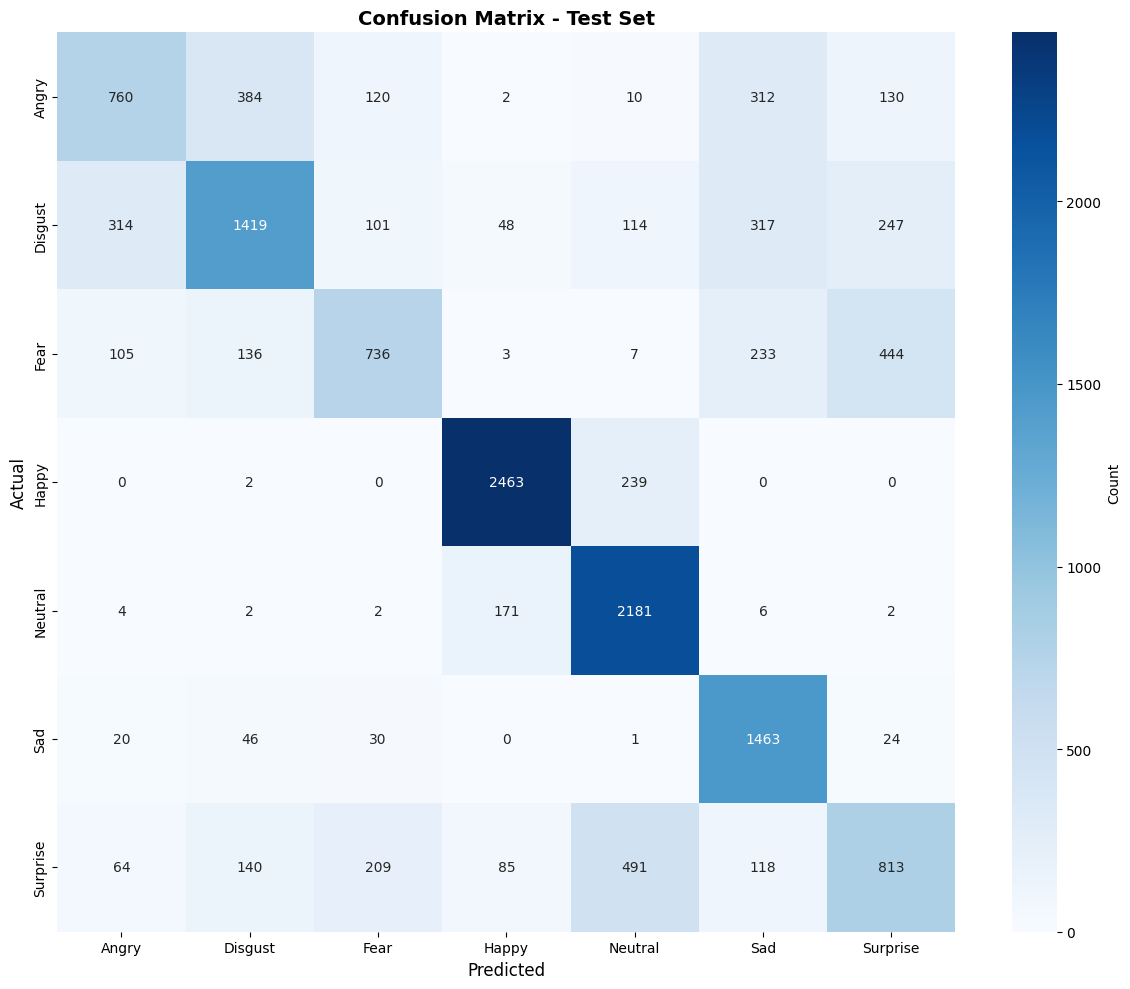


Most Confused Pairs:
Angry misclassified as Disgust: 384 times (22.4%)
Angry misclassified as Fear: 120 times (7.0%)
Angry misclassified as Sad: 312 times (18.2%)
Angry misclassified as Surprise: 130 times (7.6%)
Disgust misclassified as Angry: 314 times (12.3%)
Disgust misclassified as Fear: 101 times (3.9%)
Disgust misclassified as Neutral: 114 times (4.5%)
Disgust misclassified as Sad: 317 times (12.4%)
Disgust misclassified as Surprise: 247 times (9.6%)
Fear misclassified as Angry: 105 times (6.3%)
Fear misclassified as Disgust: 136 times (8.2%)
Fear misclassified as Sad: 233 times (14.0%)
Fear misclassified as Surprise: 444 times (26.7%)
Happy misclassified as Neutral: 239 times (8.8%)
Neutral misclassified as Happy: 171 times (7.2%)
Surprise misclassified as Disgust: 140 times (7.3%)
Surprise misclassified as Fear: 209 times (10.9%)
Surprise misclassified as Neutral: 491 times (25.6%)
Surprise misclassified as Sad: 118 times (6.1%)


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_classes, 
            yticklabels=emotion_classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMost Confused Pairs:")
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i][j] > 100:
            print(f"{emotion_classes[i]} misclassified as {emotion_classes[j]}: {cm[i][j]} times ({cm[i][j]/cm[i].sum()*100:.1f}%)")

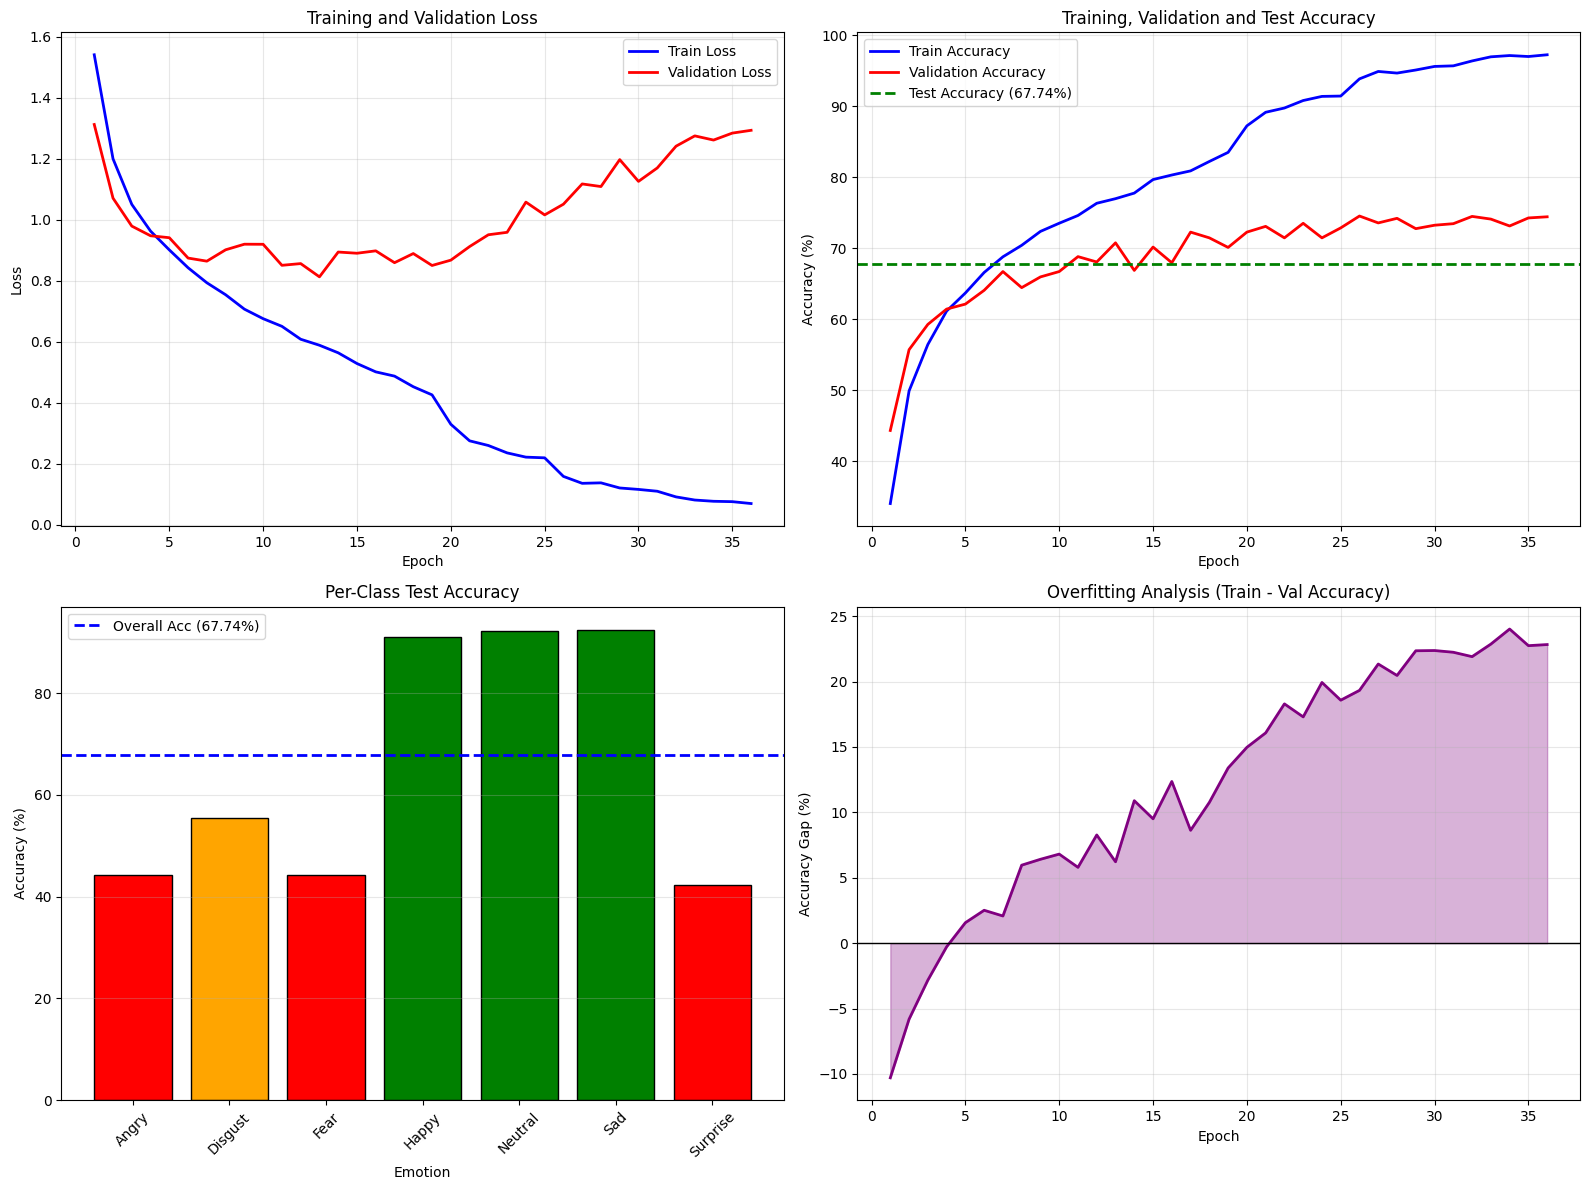

Visualization complete


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, len(train_accs)+1), train_accs, label='Train Accuracy', linewidth=2, color='blue')
axes[0, 1].plot(range(1, len(val_accs)+1), val_accs, label='Validation Accuracy', linewidth=2, color='red')
axes[0, 1].axhline(y=test_acc, color='green', linestyle='--', linewidth=2, label=f'Test Accuracy ({test_acc:.2f}%)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training, Validation and Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

per_class_accs = []
for idx in range(num_classes):
    emotion_mask = all_labels == idx
    emotion_acc = (all_preds[emotion_mask] == all_labels[emotion_mask]).mean() * 100
    per_class_accs.append(emotion_acc)

colors = ['red' if acc < 50 else 'orange' if acc < 70 else 'green' for acc in per_class_accs]
axes[1, 0].bar(emotion_classes, per_class_accs, color=colors, edgecolor='black')
axes[1, 0].axhline(y=test_acc, color='blue', linestyle='--', linewidth=2, label=f'Overall Acc ({test_acc:.2f}%)')
axes[1, 0].set_xlabel('Emotion')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Per-Class Test Accuracy')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

overfitting_gap = [train_accs[i] - val_accs[i] for i in range(len(train_accs))]
axes[1, 1].plot(range(1, len(overfitting_gap)+1), overfitting_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].fill_between(range(1, len(overfitting_gap)+1), overfitting_gap, 0, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Gap (%)')
axes[1, 1].set_title('Overfitting Analysis (Train - Val Accuracy)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete")

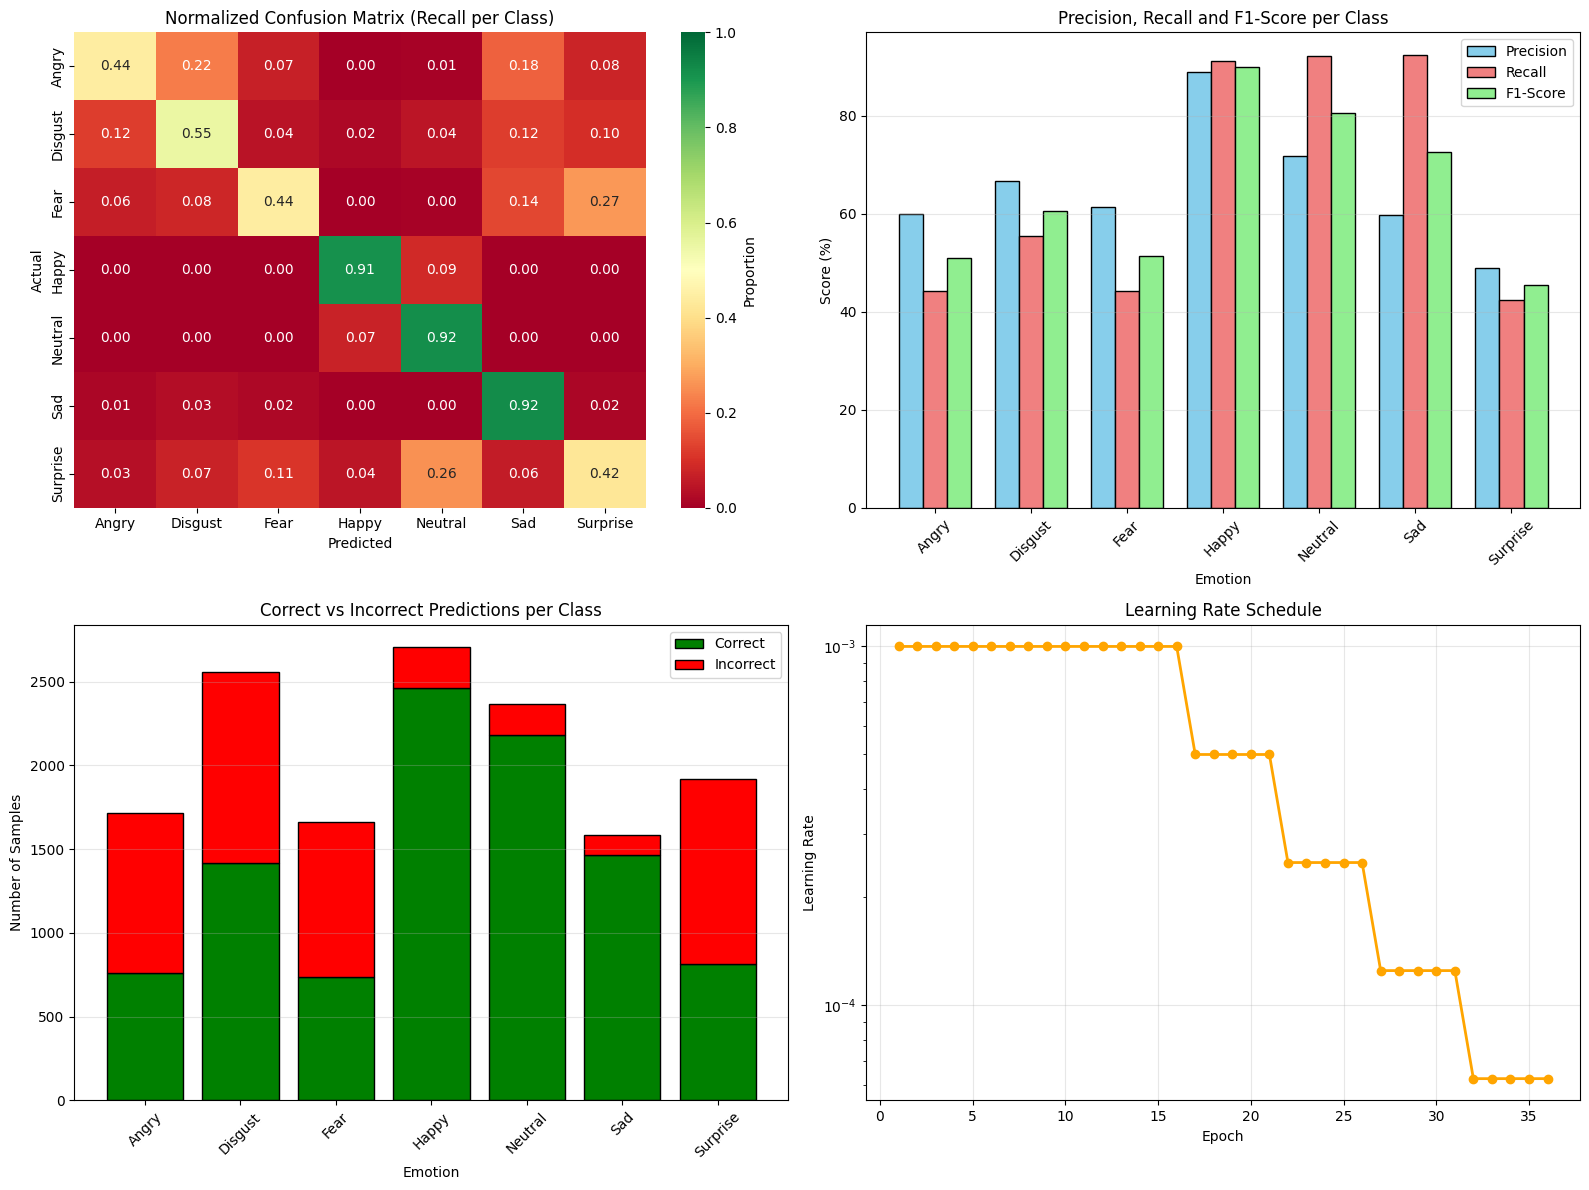

visualizations complete


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=emotion_classes, 
            yticklabels=emotion_classes,
            vmin=0, vmax=1,
            ax=axes[0, 0],
            cbar_kws={'label': 'Proportion'})
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Normalized Confusion Matrix (Recall per Class)')

precisions = []
recalls = []
f1_scores = []

for idx in range(num_classes):
    tp = cm[idx, idx]
    fp = cm[:, idx].sum() - tp
    fn = cm[idx, :].sum() - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    precisions.append(precision * 100)
    recalls.append(recall * 100)
    f1_scores.append(f1 * 100)

x = np.arange(len(emotion_classes))
width = 0.25

axes[0, 1].bar(x - width, precisions, width, label='Precision', color='skyblue', edgecolor='black')
axes[0, 1].bar(x, recalls, width, label='Recall', color='lightcoral', edgecolor='black')
axes[0, 1].bar(x + width, f1_scores, width, label='F1-Score', color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Emotion')
axes[0, 1].set_ylabel('Score (%)')
axes[0, 1].set_title('Precision, Recall and F1-Score per Class')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(emotion_classes, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

class_support = [cm[idx].sum() for idx in range(num_classes)]
class_correct = [cm[idx, idx] for idx in range(num_classes)]
class_incorrect = [class_support[idx] - class_correct[idx] for idx in range(num_classes)]

axes[1, 0].bar(emotion_classes, class_correct, label='Correct', color='green', edgecolor='black')
axes[1, 0].bar(emotion_classes, class_incorrect, bottom=class_correct, label='Incorrect', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Emotion')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_title('Correct vs Incorrect Predictions per Class')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

learning_rates = []
current_lr = 0.001
for epoch in range(len(val_losses)):
    learning_rates.append(current_lr)
    if epoch > 0 and epoch % 5 == 0:
        if val_losses[epoch] >= val_losses[epoch-1]:
            current_lr *= 0.5

axes[1, 1].plot(range(1, len(learning_rates)+1), learning_rates, linewidth=2, color='orange', marker='o')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("visualizations complete")

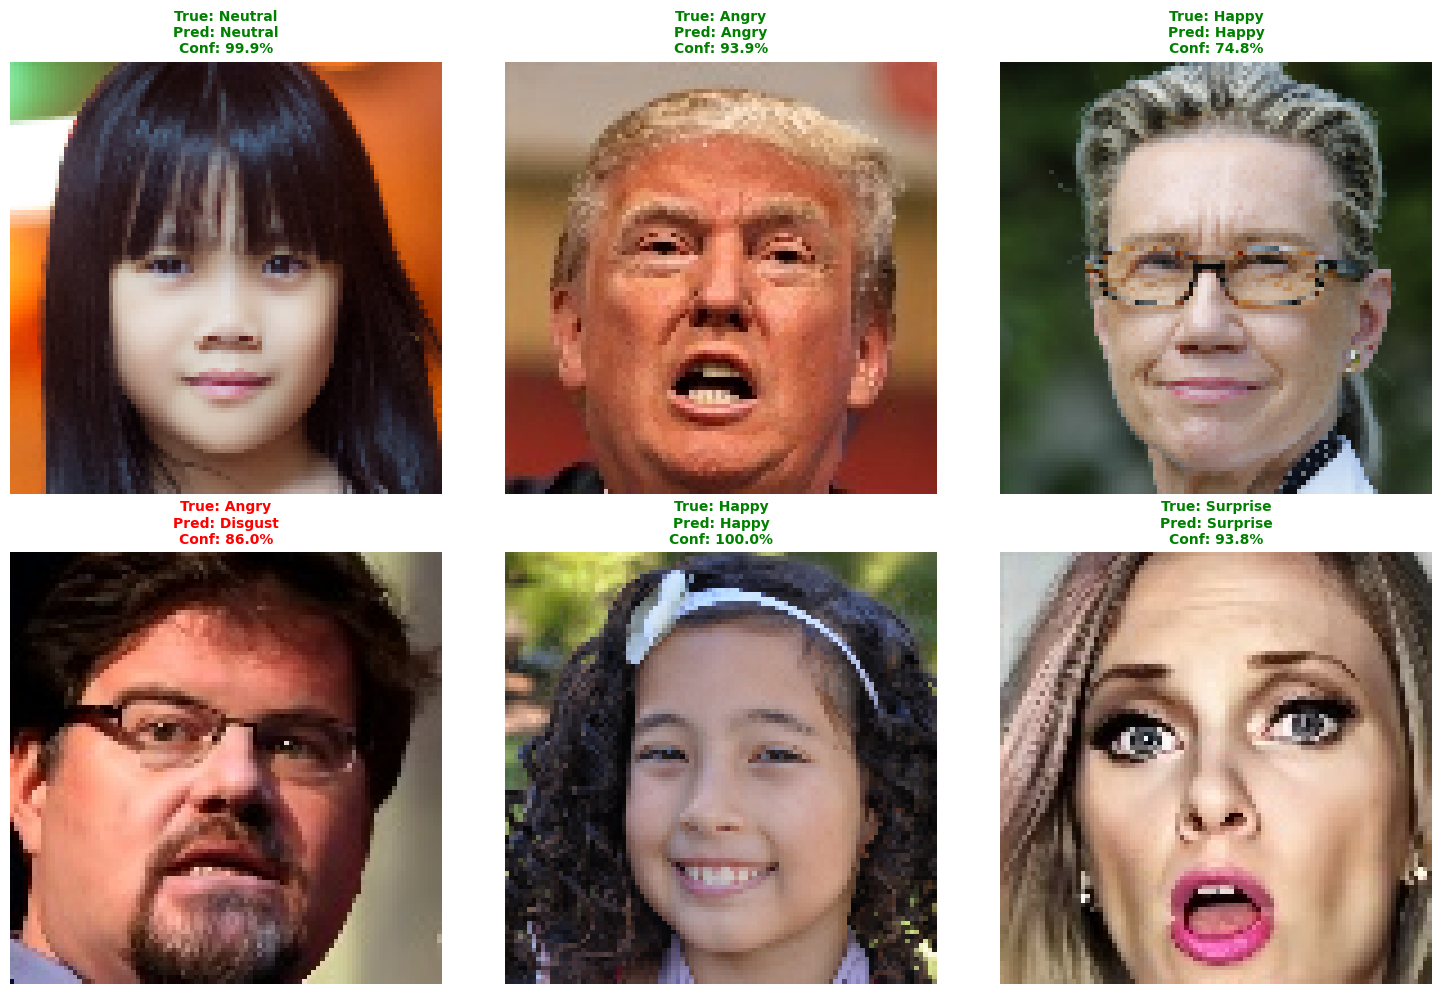

Random test predictions displayed


In [29]:
import random

random_indices = random.sample(range(len(test_df)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

model.eval()

for idx, test_idx in enumerate(random_indices):
    img_path = test_df.iloc[test_idx]['path']
    true_emotion = test_df.iloc[test_idx]['emotion']
    true_label = emotion_to_label[true_emotion]
    
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_label = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][pred_label].item() * 100
    
    pred_emotion = label_to_emotion[pred_label]
    
    img_display = cv2.imread(img_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_display)
    axes[idx].axis('off')
    
    color = 'green' if pred_emotion == true_emotion else 'red'
    title = f"True: {true_emotion}\nPred: {pred_emotion}\nConf: {confidence:.1f}%"
    axes[idx].set_title(title, fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print("Random test predictions displayed")

In [22]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handlers = []
        
        handler1 = self.target_layer.register_forward_hook(self.save_activation)
        handler2 = self.target_layer.register_backward_hook(self.save_gradient)
        self.handlers.extend([handler1, handler2])
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, target_class=None):
        model_output = self.model(input_image)
        
        if target_class is None:
            target_class = model_output.argmax(dim=1).item()
        
        self.model.zero_grad()
        model_output[0, target_class].backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        activations = self.activations[0]
        
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(activations, dim=0)
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        
        return heatmap.cpu().numpy(), target_class
    
    def remove_handlers(self):
        for handler in self.handlers:
            handler.remove()

model.zero_grad()

target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

print("GradCAM initialized successfully")
print(f"Target layer: {target_layer}")

GradCAM initialized successfully
Target layer: Conv2dNormActivation(
  (0): Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1408, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


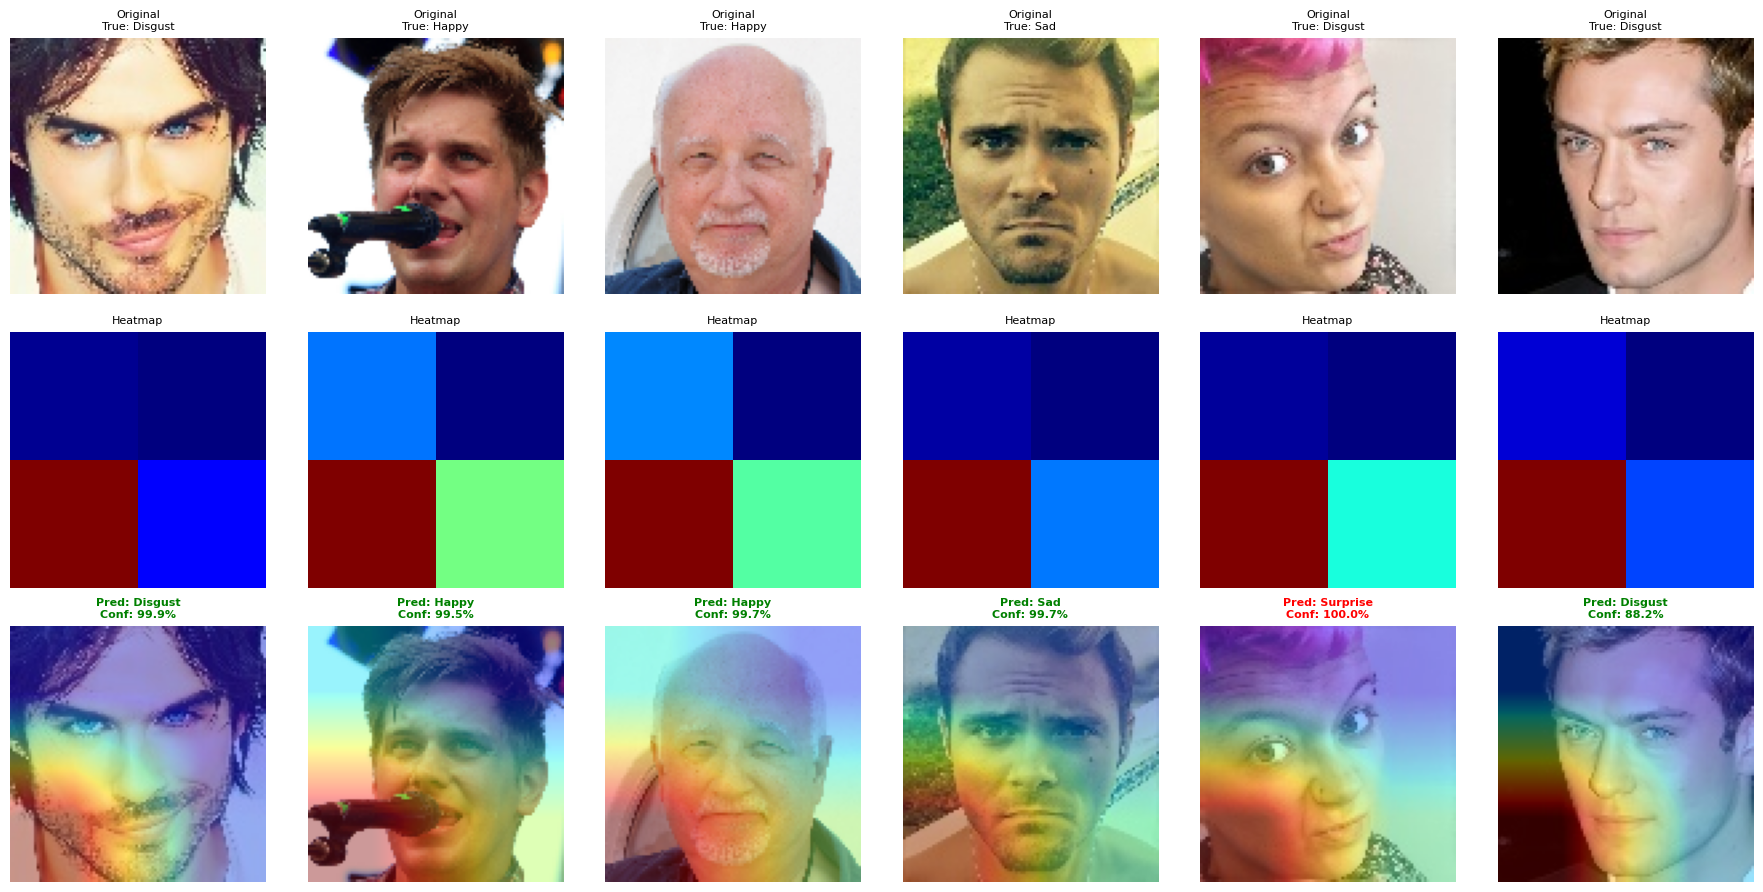

GradCAM visualization complete


In [23]:
import matplotlib.pyplot as plt
from matplotlib import cm

def apply_gradcam_overlay(image, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)
    
    overlay = cv2.addWeighted(image, 1-alpha, heatmap_colored, alpha, 0)
    return overlay

random_indices = random.sample(range(len(test_df)), 6)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))

model.eval()

for col_idx, test_idx in enumerate(random_indices):
    img_path = test_df.iloc[test_idx]['path']
    true_emotion = test_df.iloc[test_idx]['emotion']
    
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_label = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][pred_label].item() * 100
    
    pred_emotion = label_to_emotion[pred_label]
    
    heatmap, _ = gradcam.generate_cam(image_tensor, target_class=pred_label)
    
    img_display = cv2.imread(img_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    overlay = apply_gradcam_overlay(img_display, heatmap)
    
    axes[0, col_idx].imshow(img_display)
    axes[0, col_idx].axis('off')
    axes[0, col_idx].set_title(f"Original\nTrue: {true_emotion}", fontsize=8)
    
    axes[1, col_idx].imshow(heatmap, cmap='jet')
    axes[1, col_idx].axis('off')
    axes[1, col_idx].set_title(f"Heatmap", fontsize=8)
    
    color = 'green' if pred_emotion == true_emotion else 'red'
    axes[2, col_idx].imshow(overlay)
    axes[2, col_idx].axis('off')
    axes[2, col_idx].set_title(f"Pred: {pred_emotion}\nConf: {confidence:.1f}%", 
                                fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print("GradCAM visualization complete")

In [24]:
import json

model_info = {
    'model_name': 'EfficientNet-B2',
    'num_classes': num_classes,
    'emotion_classes': emotion_classes,
    'emotion_to_label': emotion_to_label,
    'label_to_emotion': label_to_emotion,
    'img_size': img_size,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'normalization_mean': [0.485, 0.456, 0.406],
    'normalization_std': [0.229, 0.224, 0.225]
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print("Model info saved to model_info.json")
print("\nFiles to download from Kaggle:")
print("1. best_emotion_model.pth")
print("2. model_info.json")

Model info saved to model_info.json

Files to download from Kaggle:
1. best_emotion_model.pth
2. model_info.json


In [25]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/model_info.json (deflated 62%)
  adding: kaggle/working/best_emotion_model.pth (deflated 7%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)


In [26]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip

True: Happy, Predicted: Happy


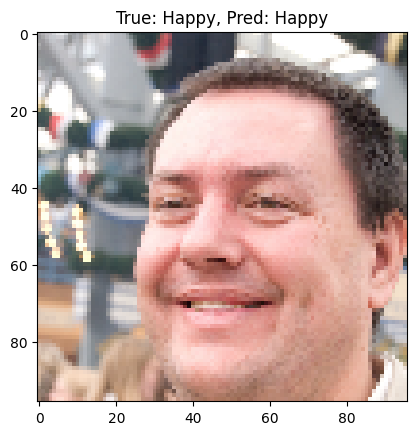

In [27]:
import random
random_idx = random.randint(0, len(test_df)-1)
img_path = test_df.iloc[random_idx]['path']
true_emotion = test_df.iloc[random_idx]['emotion']

image = Image.open(img_path).convert('RGB')
image_tensor = val_test_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    pred_label = torch.argmax(output, dim=1).item()
    pred_emotion = label_to_emotion[pred_label]

print(f"True: {true_emotion}, Predicted: {pred_emotion}")

plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"True: {true_emotion}, Pred: {pred_emotion}")
plt.show()